This notebook evaluates the learned value functions $Q_D$ and $Q_R$ on the LifeGate domain using the IQN (Implicit Quantile Network) agent. It visualises:
 1. Q-value heatmaps across the 10×10 LifeGate grid (full distribution, DRM, and CVaR views)
 2. Trajectory-level dead-end scores along sampled paths
 3. Action-value distributions at selected states

Agents are loaded from `.pkl` files saved by `run.py -ded`.

In [2]:
import io
import pickle
import os
import numpy as np
import pandas as pd

import torch

from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns

import itertools

plt.rcParams.update({'font.size': 20})

In [5]:
# ── Run to load ────────────────────────────────────────────────────────────
# Set this to the -info name used when training with run.py -ded
RUN_NAME = 'lifegate_iqn'

RUN_DIR = 'runs'
Qd_path = os.path.join("..", RUN_DIR, RUN_NAME, RUN_NAME + '_Qd.pkl')
Qr_path = os.path.join("..", RUN_DIR, RUN_NAME, RUN_NAME + '_Qr.pkl')

device = 'cpu'

print('Q_D path:', Qd_path)
print('Q_R path:', Qr_path)

Q_D path: ../runs/lifegate_iqn/lifegate_iqn_Qd.pkl
Q_R path: ../runs/lifegate_iqn/lifegate_iqn_Qr.pkl


In [6]:
import sys
sys.path.insert(0, '.')

class CpuUnpickler(pickle.Unpickler):
    """Redirect CUDA tensors to CPU and resolve renamed classes when unpickling."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu', weights_only=False)
        return super().find_class(module, name)

def load_agent(path):
    with open(path, 'rb') as f:
        agent = CpuUnpickler(f).load()
    agent.qnetwork_local.to(device)
    agent.qnetwork_local.eval()
    return agent

qd_agent = load_agent(Qd_path)
qr_agent = load_agent(Qr_path)

# Expose the networks directly so the rest of the notebook can call .forward()
iqn_d = qd_agent.qnetwork_local
iqn_r = qr_agent.qnetwork_local

print('Q_D network:', type(iqn_d).__name__, '| action_size:', iqn_d.action_size)
print('Q_R network:', type(iqn_r).__name__, '| action_size:', iqn_r.action_size)

Q_D network: IQN | action_size: 5
Q_R network: IQN | action_size: 5


In [7]:
VaR_thresh = 0.1
num_samples = 1000
VaR_cutoff = round(VaR_thresh * num_samples)

In [8]:
scr_w, scr_h = 10, 10

states = itertools.product(range(scr_w), range(scr_h))

In [9]:
scr_w, scr_h = 10, 10

states = itertools.product(range(scr_w), range(scr_h))

full_D_max  = np.zeros((scr_w, scr_h))
full_R_max  = np.zeros((scr_w, scr_h))
drm_D_max   = np.zeros((scr_w, scr_h))
drm_R_max   = np.zeros((scr_w, scr_h))
cvar_D_max  = np.zeros((scr_w, scr_h))
cvar_R_max  = np.zeros((scr_w, scr_h))

full_D_med  = np.zeros((scr_w, scr_h))
full_R_med  = np.zeros((scr_w, scr_h))
drm_D_med   = np.zeros((scr_w, scr_h))
drm_R_med   = np.zeros((scr_w, scr_h))
cvar_D_med  = np.zeros((scr_w, scr_h))
cvar_R_med  = np.zeros((scr_w, scr_h))

full_D_min  = np.zeros((scr_w, scr_h))
full_R_min  = np.zeros((scr_w, scr_h))
drm_D_min   = np.zeros((scr_w, scr_h))
drm_R_min   = np.zeros((scr_w, scr_h))
cvar_D_min  = np.zeros((scr_w, scr_h))
cvar_R_min  = np.zeros((scr_w, scr_h))

with torch.no_grad():
    for state in states:
        inp_state = torch.from_numpy(np.array(state).reshape((1, -1))).float().to(device)

        # Full distribution (no DRM)
        iqn_d_vals, _ = iqn_d.forward(inp_state, num_samples, use_drm=False)
        iqn_r_vals, _ = iqn_r.forward(inp_state, num_samples, use_drm=False)

        # DRM-weighted distribution
        iqn_d_vals_drm, _ = iqn_d.forward(inp_state, num_samples, use_drm=True)
        iqn_r_vals_drm, _ = iqn_r.forward(inp_state, num_samples, use_drm=True)

        # Convert to numpy; shape (num_samples, action_size)
        iqn_d_vals     = np.sort(iqn_d_vals.squeeze().numpy(),     axis=0)
        iqn_r_vals     = np.sort(iqn_r_vals.squeeze().numpy(),     axis=0)
        iqn_d_vals_drm = iqn_d_vals_drm.squeeze().numpy()
        iqn_r_vals_drm = iqn_r_vals_drm.squeeze().numpy()

        # CVaR tail
        iqn_d_vals_var = iqn_d_vals[:VaR_cutoff, :]
        iqn_r_vals_var = iqn_r_vals[:VaR_cutoff, :]

        # Per-action means
        mean_d      = np.mean(iqn_d_vals,     axis=0)
        mean_d_drm  = np.mean(iqn_d_vals_drm, axis=0)
        mean_d_var  = np.mean(iqn_d_vals_var, axis=0)

        mean_r      = np.mean(iqn_r_vals,     axis=0)
        mean_r_drm  = np.mean(iqn_r_vals_drm, axis=0)
        mean_r_var  = np.mean(iqn_r_vals_var, axis=0)

        # Record max / median / min over actions
        full_D_max[state]  = max(mean_d);      full_R_max[state]  = max(mean_r)
        drm_D_max[state]   = max(mean_d_drm);  drm_R_max[state]   = max(mean_r_drm)
        cvar_D_max[state]  = max(mean_d_var);  cvar_R_max[state]  = max(mean_r_var)

        full_D_med[state]  = np.median(mean_d);      full_R_med[state]  = np.median(mean_r)
        drm_D_med[state]   = np.median(mean_d_drm);  drm_R_med[state]   = np.median(mean_r_drm)
        cvar_D_med[state]  = np.median(mean_d_var);  cvar_R_med[state]  = np.median(mean_r_var)

        full_D_min[state]  = min(mean_d);      full_R_min[state]  = min(mean_r)
        drm_D_min[state]   = min(mean_d_drm);  drm_R_min[state]   = min(mean_r_drm)
        cvar_D_min[state]  = min(mean_d_var);  cvar_R_min[state]  = min(mean_r_var)

### NOW VISUALIZE THESE WITH HEATMAPS!

In [10]:
# RGB colors
WHITE  = np.array((255, 255, 255, 255)) / 255
BLACK  = np.array((0,   0,   0,   255)) / 255
RED    = np.array((255, 0,   0,   255)) / 255
BLUE   = np.array((0,   100, 255, 255)) / 255
GREEN  = np.array((0,   255, 0,   255)) / 255
WALL   = np.array((80,  80,  80,  255)) / 255
YELLOW = np.array((255, 255, 0,   255)) / 255
YL_RD  = np.array((255, 165, 0,   255)) / 255

scr_w, scr_h = 10, 10
barriers  = [[0, 0], [1, 0], [2, 0], [3, 0], [4, 0], [1, 5], [2, 5], [3, 5], [4, 5]]
lifes     = [[5, 0], [6, 0], [7, 0]]
deaths    = [[scr_w - 1, k] for k in range(scr_h)] + [[8, 0]]
deadends  = [[x, y] for x in range(scr_w // 2 + 1, scr_w - 1) for y in range(3 * scr_w // 4, scr_w)]
risk_zone = [[x, y] for x in range(scr_w // 2, scr_w - 1) for y in range(scr_w // 2, scr_w) if [x, y] not in deadends]

def annotate_image(img):
    for wall in barriers:
        img[wall[1], wall[0], :] = WALL
    for life in lifes:
        img[life[1], life[0], :] = BLUE
    for death in deaths:
        img[death[1], death[0], :] = RED
    return img

def build_lg_image(img):
    img = annotate_image(img)
    for de in deadends:
        img[de[1], de[0], :] = YL_RD
    for rz in risk_zone:
        img[rz[1], rz[0], :] = YL_RD
    return img

cmap = plt.cm.RdBu
norm = plt.Normalize(-1., 1.)

## Plot Q value heatmaps

### Full Value Distribution (D-Network)

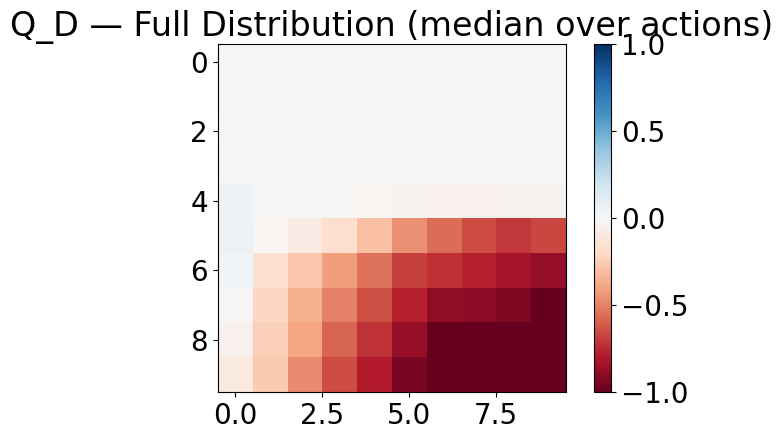

In [11]:
plt.figure()
plt.imshow(full_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_D — Full Distribution (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

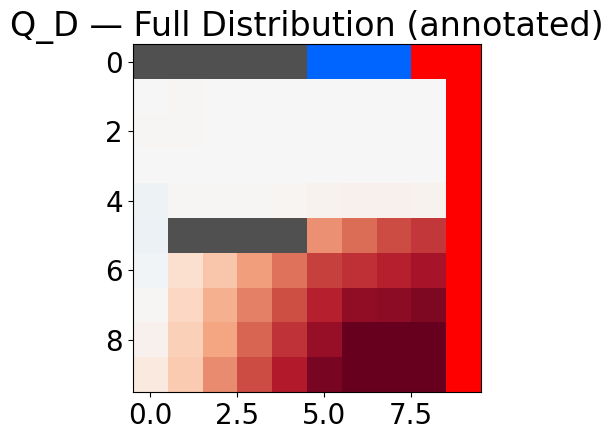

In [12]:
plt.figure()
temp = full_D_med
img  = cmap(norm(temp))
img  = annotate_image(img)
plt.imshow(img)
plt.title('Q_D — Full Distribution (annotated)')
plt.tight_layout()
plt.show()
plt.close()

### DRM version (D-Network)

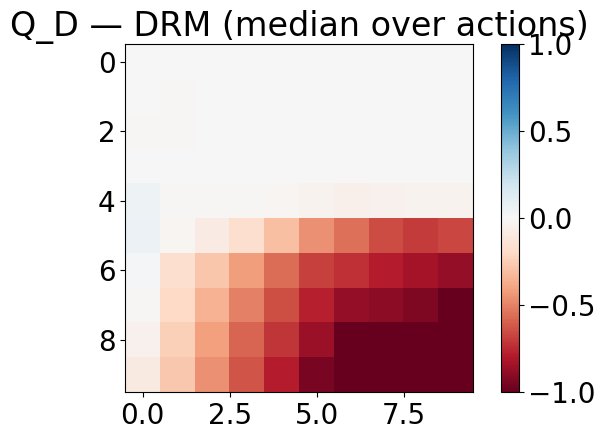

In [13]:
plt.figure()
plt.imshow(drm_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_D — DRM (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

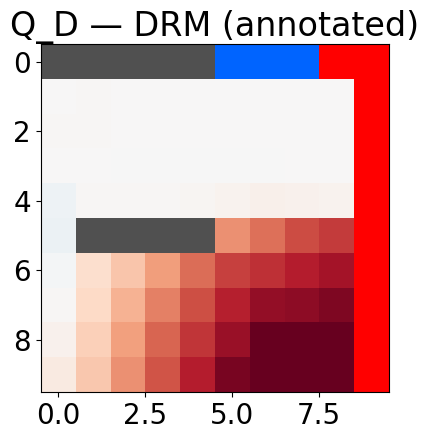

In [14]:
plt.figure()
temp = drm_D_med
img  = cmap(norm(temp))
img  = annotate_image(img)
im   = plt.imshow(img)
plt.title('Q_D — DRM (annotated)')
plt.tight_layout()
plt.show()
plt.close()

### CVaR version (D-Network)

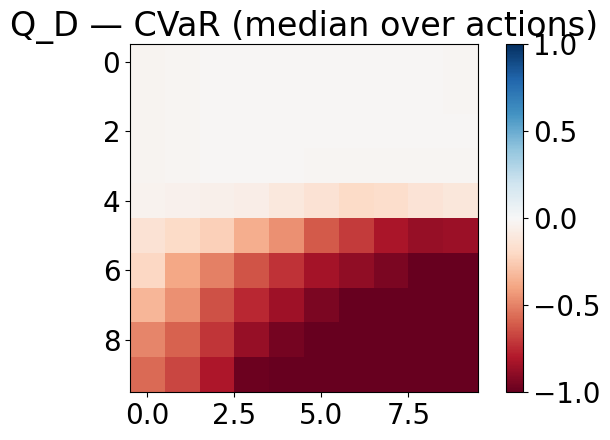

In [15]:
plt.figure()
plt.imshow(cvar_D_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_D — CVaR (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

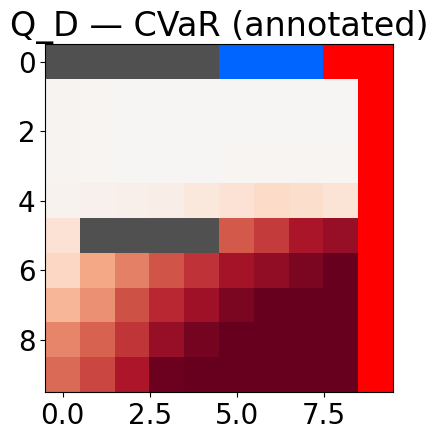

In [16]:
plt.figure()
temp = cvar_D_med
img  = cmap(norm(temp))
img  = annotate_image(img)
im   = plt.imshow(img)
plt.title('Q_D — CVaR (annotated)')
plt.tight_layout()
plt.show()
plt.close()

### Full Distribution (R-Network)

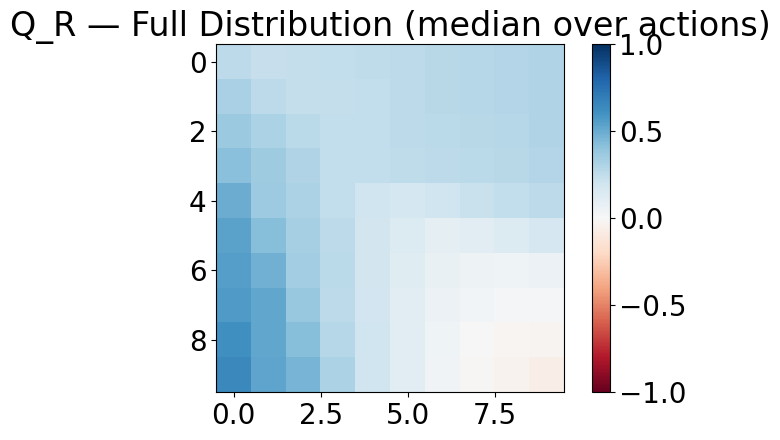

In [17]:
plt.figure()
plt.imshow(full_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_R — Full Distribution (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
plt.figure()
temp = full_R_med
img  = cmap(norm(temp))
img  = annotate_image(img)
plt.imshow(img)
plt.title('Q_R — Full Distribution (annotated)')
plt.tight_layout()
plt.show()
plt.close()

### DRM Distribution (R-Network)

In [ ]:
plt.figure()
plt.imshow(drm_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_R — DRM (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
plt.figure()
temp = drm_R_med
img  = cmap(norm(temp))
img  = annotate_image(img)
plt.imshow(img)
plt.title('Q_R — DRM (annotated)')
plt.tight_layout()
plt.show()
plt.close()

### CVaR Distribution (R-Network)

In [ ]:
plt.figure()
plt.imshow(cvar_R_med, vmin=-1., vmax=1., cmap='RdBu')
plt.colorbar()
plt.title('Q_R — CVaR (median over actions)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
plt.figure()
temp = cvar_R_med
img  = cmap(norm(temp))
img  = annotate_image(img)
plt.imshow(img)
plt.title('Q_R — CVaR (annotated)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
norm2 = matplotlib.colors.Normalize(-1, 0)
colors = [
    [norm2(-1.0),  'xkcd:tomato'],
    [norm2(-0.85), 'xkcd:tomato'],
    [norm2(-0.75), 'xkcd:custard'],
    [norm2(-0.6),  'white'],
    [norm2(-0.4),  'white'],
    [norm2(0.0),   'white'],
]
cmap2 = matplotlib.colors.LinearSegmentedColormap.from_list('', colors)

fig, ax = plt.subplots()
x = np.arange(10)
y = np.linspace(-1, 0, 10)
sc = ax.scatter(x, y, c=y, norm=norm2, cmap=cmap2)
fig.colorbar(sc, orientation='horizontal')
plt.show()

## Trajectory-level dead-end scores

In [ ]:
trajectory_x = [9, 9, 9, 9, 9, 8, 8, 7, 7, 6, 6, 5, 4, 3, 2, 1, 0, 0, 0, 0]
trajectory_y = [1, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

traj1b_x = [9, 9, 9, 9, 9, 8, 8, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
traj1b_y = [1, 1, 1, 1, 2, 2, 2, 3, 4, 4, 5, 5, 5, 6, 7, 8, 9, 9, 9, 9, 9]

traj2_x = [9, 9, 9, 9, 9, 8, 8, 7, 6, 5, 4, 4, 3, 3, 2, 2, 2, 1, 1, 0, 0, 0, 0]
traj2_y = [1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 1, 1, 2, 2, 3, 4, 4, 5, 5, 5, 5, 5]

traj3_x = [9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 7, 7, 6, 5, 4, 3, 2, 1, 0, 0, 0, 0]
traj3_y = [1, 1, 1, 1, 2, 3, 4, 4, 5, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]

traj3b_x = [9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
traj3b_y = [1, 1, 1, 1, 2, 2, 3, 3, 3, 4, 5, 6, 7, 8, 9, 9, 9, 9, 9, 9, 9, 9]

In [ ]:
window_size = 5

def moving_avg(data):
    cs = np.cumsum(np.insert(data, 0, 0))
    return (cs[window_size:] - cs[:-window_size]) / window_size

def interpolate_vector(data, factor):
    n  = len(data)
    x  = np.linspace(0, n - 1, (n - 1) * factor + 1)
    xp = np.arange(n)
    return np.interp(x, xp, np.asarray(data))

ma_x,   ma_y   = moving_avg(trajectory_x), moving_avg(trajectory_y)
ma1b_x, ma1b_y = moving_avg(traj1b_x),     moving_avg(traj1b_y)
ma2_x,  ma2_y  = moving_avg(traj2_x),      moving_avg(traj2_y)
ma3_x,  ma3_y  = moving_avg(traj3_x),      moving_avg(traj3_y)
ma3b_x, ma3b_y = moving_avg(traj3b_x),     moving_avg(traj3b_y)

ma_int_x,   ma_int_y   = interpolate_vector(ma_x,   10), interpolate_vector(ma_y,   10)
ma1b_int_x, ma1b_int_y = interpolate_vector(ma1b_x, 10), interpolate_vector(ma1b_y, 10)
ma2_int_x,  ma2_int_y  = interpolate_vector(ma2_x,  10), interpolate_vector(ma2_y,  10)
ma3_int_x,  ma3_int_y  = interpolate_vector(ma3_x,  10), interpolate_vector(ma3_y,  10)
ma3b_int_x, ma3b_int_y = interpolate_vector(ma3b_x, 10), interpolate_vector(ma3b_y, 10)

In [ ]:
plt.figure()
lg_img = np.zeros((10, 10, 4))
lg_img[..., -1] = 1
lg_img = build_lg_image(lg_img)
plt.tight_layout()
plt.imshow(lg_img)
plt.scatter(trajectory_y,  trajectory_x,  c='white', marker='s')
plt.scatter(ma_int_y,      ma_int_x,      c='white', marker='o')
plt.scatter(traj1b_y,      traj1b_x,      c='black', marker='s')
plt.scatter(ma1b_int_y,    ma1b_int_x,    c='black', marker='o')
plt.scatter(traj2_y,       traj2_x,       c='green', marker='s')
plt.scatter(ma2_int_y,     ma2_int_x,     c='darkgreen', marker='o')
plt.scatter(traj3_y,       traj3_x,       c='red',   marker='s')
plt.scatter(ma3_int_y,     ma3_int_x,     c='red',   marker='o')
plt.scatter(traj3b_y,      traj3b_x,      c='black', marker='s')
plt.scatter(ma3b_int_y,    ma3b_int_x,    c='black', marker='o')
ax = plt.gca()
plt.setp(ax.spines.values(), alpha=0)
ax.tick_params(which='both', size=0, labelsize=0)
plt.show()

In [ ]:
traj_values = []

with torch.no_grad():
    for traj in [list(zip(ma_int_y, ma_int_x)),
                 list(zip(ma2_int_y, ma2_int_x)),
                 list(zip(ma3_int_y, ma3_int_x)),
                 list(zip(ma1b_int_y, ma1b_int_x)),
                 list(zip(ma3b_int_y, ma3b_int_x))]:
        traj_value = {'iqn_d': [], 'iqn_r': [], 'iqn_comb': []}
        for state in traj:
            inp_state = torch.from_numpy(np.array(state).reshape((1, -1))).float().to(device)

            d_vals, _ = iqn_d.forward(inp_state, num_samples, use_drm=False)
            r_vals, _ = iqn_r.forward(inp_state, num_samples, use_drm=False)

            d_vals = np.sort(d_vals.squeeze().numpy(), axis=0)
            r_vals = np.sort(r_vals.squeeze().numpy(), axis=0)

            d_var = d_vals[:VaR_cutoff, :]
            r_var = r_vals[:VaR_cutoff, :]

            comb = np.mean([
                np.median(np.clip(d_var, -1., 0.).mean(0)),
                np.median(np.clip(r_var, 0., 1.).mean(0)) - 1.
            ])

            traj_value['iqn_d'].append(np.median(d_var.mean(0)))
            traj_value['iqn_r'].append(np.median(r_var.mean(0)))
            traj_value['iqn_comb'].append(np.clip(comb, -1., 0.))

        traj_values.append(traj_value)

In [ ]:
plt.figure(figsize=(8, 8))
lg_img = np.zeros((10, 10, 4))
lg_img[..., -1] = 1
lg_img = build_lg_image(lg_img)
plt.tight_layout()
plt.imshow(lg_img)

plt.plot(ma_int_y,  ma_int_x,  color='gray', linestyle='--', lw=4, zorder=1)
plt.scatter(ma1b_int_y, ma1b_int_x, c=traj_values[3]['iqn_comb'], marker='o', s=150, cmap=cmap2, zorder=2)
plt.scatter(ma2_int_y,  ma2_int_x,  c=traj_values[1]['iqn_comb'], marker='o', s=150, cmap=cmap2)
plt.plot(ma3_int_y,  ma3_int_x,  color='gray', linestyle='--', lw=4, zorder=1)
plt.scatter(ma3b_int_y, ma3b_int_x, c=traj_values[4]['iqn_comb'], marker='o', s=150, cmap=cmap2, zorder=2)
ax = plt.gca()
plt.setp(ax.spines.values(), alpha=0)
ax.tick_params(which='both', size=0, labelsize=0)
plt.show()

## Action-Value Distributions at a selected state

In [ ]:
num_samples = 1000

# Change (x, y) to inspect a different state
inp_state = torch.from_numpy(np.array([6, 2]).reshape((1, -1))).float().to(device)

with torch.no_grad():
    iqn_d_vals,     _ = iqn_d.forward(inp_state, num_samples, use_drm=False)
    iqn_d_vals_drm, _ = iqn_d.forward(inp_state, num_samples, use_drm=True)
    iqn_r_vals,     _ = iqn_r.forward(inp_state, num_samples, use_drm=False)
    iqn_r_vals_drm, _ = iqn_r.forward(inp_state, num_samples, use_drm=True)

data     = np.sort(iqn_d_vals.squeeze().numpy(),     axis=0)
data_drm = iqn_d_vals_drm.squeeze().numpy()
data_var = data[:100, :]

df      = pd.DataFrame(data)
df_drm  = pd.DataFrame(data_drm)
df_var  = pd.DataFrame(data_var)

In [ ]:
action_count = iqn_d.action_size
action_ids   = list(range(action_count))

df2     = pd.melt(df,     value_vars=action_ids, var_name='action'); df2['drm']     = 'Full'
df2_var = pd.melt(df_var, value_vars=action_ids, var_name='action'); df2_var['drm'] = 'VaR'

big_df = pd.concat([df2, df2_var], axis=0).reset_index(drop=True)
big_df['dummy'] = 0
big_df.head()

In [ ]:
plt.rcParams.update({'font.size': 20})

types   = ['VaR', 'Full']
colors  = sns.color_palette(n_colors=2)[::-1]
actions = ['No Op', 'Up', 'Down', 'Left', 'Right'] if action_count == 5 else [str(i) for i in range(action_count)]

fig, axs = plt.subplots(action_count, figsize=(6, 5 * action_count))
if action_count == 1:
    axs = [axs]

for act in range(action_count):
    temp    = big_df[big_df.action == act]
    ax_obj  = axs[act]
    g       = sns.kdeplot(data=temp, x='value', lw=6, hue='drm', legend=False, ax=ax_obj)
    ax_line = g.axes
    for ii, typ in enumerate(types):
        d    = temp[temp.drm == typ]['value'].values
        xs, ys = ax_line.get_lines()[ii].get_data()
        mean = d.mean()
        sdev = d.std()
        ax_line.vlines([mean - sdev, mean, mean + sdev], 0,
                       np.interp([mean - sdev, mean, mean + sdev], xs, ys),
                       color=colors[ii], ls=':', lw=2)
        ax_line.vlines(mean, 0, np.interp(mean, xs, ys), color=colors[ii], ls='--', lw=4)
    ax_line.vlines(-0.75, 0, 5.0, color='red', ls=':', lw=4)

    ax_obj.grid()
    ax_obj.set_xlim([-1.05, 0])
    ax_obj.set_yticklabels([])
    ax_obj.set_ylabel('')
    ax_obj.set_xlabel('')
    ax_obj.text(0.01, 0.95, f'Action {act}: {actions[act]}',
                transform=ax_line.transAxes, size=18, weight='bold',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.85))

plt.tight_layout()
plt.show()